There are n cities. Some of them are connected, while some are not. If city a is connected directly with city b, and city b is connected directly with city c, then city a is connected indirectly with city c.

A province is a group of directly or indirectly connected cities and no other cities outside of the group.

You are given an n x n matrix isConnected where isConnected[i][j] = 1 if the ith city and the jth city are directly connected, and isConnected[i][j] = 0 otherwise.

Return the total number of provinces.

Example 1:

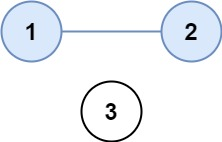

Input: isConnected = [[1,1,0],[1,1,0],[0,0,1]]
Output: 2

Example 2:

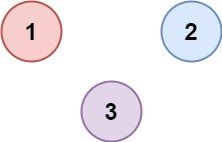

Input: isConnected = [[1,0,0],[0,1,0],[0,0,1]]
Output: 3

constraints:

1 <= n <= 200
n == isConnected.length
n == isConnected[i].length
isConnected[i][j] is 1 or 0.
isConnected[i][i] == 1
isConnected[i][j] == isConnected[j][i]

In [1]:
from typing import List

# A classe Solution com a lógica de DFS Iterativo (Padrão Uber)
class Solution:
    def findCircleNum(self, isConnected: List[List[int]]) -> int:
        total_provinces = 0
        visited = set()
        total_cities = len(isConnected)
        
        for city_index in range(total_cities):
            if city_index in visited:
                continue
            
            # Se chegamos aqui, achamos o início de uma nova província
            total_provinces += 1
            stack = [city_index]
            visited.add(city_index)
            
            while stack:
                current_city = stack.pop()
                
                # Olhamos para todos os potenciais vizinhos desta cidade
                for neighbor in range(total_cities):
                    # Pule se não há conexão ou se já foi visitado
                    if isConnected[current_city][neighbor] == 0 or neighbor in visited:
                        continue
                    stack.append(neighbor)
                    visited.add(neighbor)

            return total_provinces

# --- CLIENT CODE PARA TESTE ---

def run_tests():
    sol = Solution()
    
    # Caso 1: Duas províncias separadas
    # Cidade 0 conectada a 1. Cidade 2 isolada.
    case1 = [
        [1, 1, 0],
        [1, 1, 0],
        [0, 0, 1]
    ]
    print(f"Teste 1 - Esperado: 2 | Resultado: {sol.findCircleNum(case1)}")
    
    # Caso 2: Três províncias (todas as cidades isoladas)
    case2 = [
        [1, 0, 0],
        [0, 1, 0],
        [0, 0, 1]
    ]
    print(f"Teste 2 - Esperado: 3 | Resultado: {sol.findCircleNum(case2)}")
    
    # Caso 3: Uma única província (todos conectados em cadeia: 0-1-2)
    case3 = [
        [1, 1, 0],
        [1, 1, 1],
        [0, 1, 1]
    ]
    print(f"Teste 3 - Esperado: 1 | Resultado: {sol.findCircleNum(case3)}")

    # Caso 4: Grafo vazio ou com uma única cidade
    case4 = [[1]]
    print(f"Teste 4 - Esperado: 1 | Resultado: {sol.findCircleNum(case4)}")

if __name__ == "__main__":
    run_tests()

Teste 1 - Esperado: 2 | Resultado: 1
Teste 2 - Esperado: 3 | Resultado: 1
Teste 3 - Esperado: 1 | Resultado: 1
Teste 4 - Esperado: 1 | Resultado: 1
